# Underwater Vehicle Tracking Simulation

This notebook simulates a multi-camera system tracking an underwater vehicle in a water tank using Kalman filters.

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R
from math import pi

import time as pytime
time_seed = int(pytime.time())
np.random.seed(time_seed)

## 1. Define the Water Tank Environment

In [83]:
class WaterTank:
    def __init__(self, length=1, width=1, height=0.5):
        self.length = length
        self.width = width
        self.height = height
        
    def plot_tank(self, ax):
        # Plot tank boundaries
        x = [0, self.length, self.length, 0, 0]
        y = [0, 0, self.width, self.width, 0]
        z = [0, 0, 0, 0, 0]
        ax.plot(x, y, z, 'b-')
        
        # Plot top surface
        x = [0, self.length, self.length, 0, 0]
        y = [0, 0, self.width, self.width, 0]
        z = [self.height, self.height, self.height, self.height, self.height]
        ax.plot(x, y, z, 'b-')
        
        # Plot vertical edges
        for i in range(4):
            ax.plot([x[i], x[i]], [y[i], y[i]], [0, self.height], 'b-')

## 2. Define the Underwater Vehicle

In [84]:
class UnderwaterVehicle:
    def __init__(self, initial_position, initial_velocity):
        self.position = np.array(initial_position)
        self.velocity = np.array(initial_velocity)
        self.trajectory = [self.position.copy()]
        
    def update(self, dt):
        # Simple motion model with some random movement
        self.position += self.velocity * dt
        self.velocity += np.random.normal(0, 0.01, 3)  # Add some random noise
        self.trajectory.append(self.position.copy())
        
    def plot_vehicle(self, ax):
        ax.scatter(self.position[0], self.position[1], self.position[2], 
                  color='red', s=100, label='Vehicle')
        
        # Plot trajectory
        trajectory = np.array(self.trajectory)
        ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], 
                'r--', alpha=0.5, label='Trajectory')

## 3. Define the Camera System

To calculate the image plane position from the world position, we need the following steps:

### Find the relative position of the world point to the camera

$$
\begin{bmatrix} x_{relative} \\ y_{relative} \\ z_{relative} \\ 1 \end{bmatrix} =  P \begin{bmatrix} x_{world} \\ y_{world} \\ z_{world} \\ 1 \end{bmatrix}
$$

Where $P$ is the homogeneous transformation matrix of the camera.

$$P = \begin{bmatrix} c \phi c \theta c\psi - s\phi s\psi & -c \phi c \theta s\psi - s\phi c\psi & c \phi s \theta & -x_{camera} \\ s\phi c \theta c\psi + c\phi s\psi & -s\phi c \theta s\psi + c\phi c\psi & s\phi s \theta & -y_{camera} \\ -s \theta c\psi & s \theta s\psi & c \theta & -z_{camera} \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

### Find the image plane position from the relative position

$$
\lambda \begin{bmatrix} x_{image} \\ y_{image} \\ 1 \end{bmatrix} = \begin{bmatrix} f & 0 & 0 & 0 \\ 0 & f & 0 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} x_{relative} \\ y_{relative} \\ z_{relative} \\ 1 \end{bmatrix}
$$

Where $\lambda$ is an unknown scalar.









In [85]:
class Camera:
    def __init__(self, name, color, position, orientation, focal_length = 0.5, image_plane_size = (1, 1)):
        self.position = np.array(position)
        self.orientation = np.array(orientation)
        self.focal_length = focal_length
        self.image_plane_size = np.array(image_plane_size)
        self.color = color
        self.name = name
        self.P = np.zeros((4, 4))
        self.P[:3, :3] = R.from_euler('xyz', self.orientation, degrees=False).as_matrix()
        self.P[:3, 3] = -self.position
        self.P[3, 3] = 1
        print(self.P)
        self.trajectory = []
    
    def world2camera(self, world_position):
        world_position_vector = np.array([world_position[0], world_position[1], world_position[2], 1])
        camera_position_vector = self.P @ world_position_vector
        camera_position_vector = np.array([[self.focal_length, 0, 0, 0], [0, self.focal_length, 0, 0], [0, 0, 1, 0]]) @ camera_position_vector

        if camera_position_vector[0] <= -self.image_plane_size[0] / 2 or camera_position_vector[0] > self.image_plane_size[0] / 2:
            return None
        if camera_position_vector[1] <= -self.image_plane_size[1] / 2 or camera_position_vector[1] > self.image_plane_size[1] / 2:
            return None
        return camera_position_vector[:3]
    
    def capture(self, world_position, noise_std=0.0):
        image_position = self.world2camera(world_position)
        if image_position is not None:
            if noise_std > 0:
                image_position = image_position + np.random.normal(0, noise_std, 3)
            self.trajectory.append(image_position)
            return image_position
        return None

    def camera2world(self, camera_observation):
        """Back-project a camera observation [f*xc, f*yc, zc] to world coordinates."""
        xc = camera_observation[0] / self.focal_length
        yc = camera_observation[1] / self.focal_length
        zc = camera_observation[2]
        R_T = self.P[:3, :3].T
        return R_T @ (np.array([xc, yc, zc]) + self.position)
    
    def plot_camera(self, ax):
        ax.scatter(self.position[0], self.position[1], self.position[2], 
                  color=self.color, s=100, label=f'Camera {self.name}')
        # Plot camera orientation
        orientation = np.array([1, 0, 0]) @ R.from_euler('xyz', self.orientation, degrees=False).as_matrix()
        ax.quiver(self.position[0], self.position[1], self.position[2],
                 orientation[0], orientation[1], orientation[2],
                 color=self.color, length=0.1)

    def project_raw(self, world_position):
        """Perspective-project without bounds check (for EKF predicted measurement)."""
        p = np.append(np.asarray(world_position, dtype=float), 1.0)
        p_cam = self.P @ p
        xc, yc, zc = p_cam[0], p_cam[1], p_cam[2]
        if abs(zc) < 1e-10:
            return None
        u = self.focal_length * xc / zc
        v = self.focal_length * yc / zc
        return np.array([u, v])

    def project(self, world_position, noise_std=0.0):
        """Perspective-project a 3D world point to 2D image coordinates (u, v)."""
        uv = self.project_raw(world_position)
        if uv is None:
            return None
        u, v = uv
        if abs(u) > self.image_plane_size[0] / 2 or abs(v) > self.image_plane_size[1] / 2:
            return None
        if noise_std > 0:
            u += np.random.normal(0, noise_std)
            v += np.random.normal(0, noise_std)
        return np.array([u, v])

    def projection_jacobian(self, world_position):
        """Jacobian of [u, v] w.r.t. [px, py, pz] (2x3 matrix)."""
        p = np.append(np.asarray(world_position, dtype=float), 1.0)
        p_cam = self.P @ p
        xc, yc, zc = p_cam[0], p_cam[1], p_cam[2]
        Rot = self.P[:3, :3]
        f = self.focal_length

        J = np.zeros((2, 3))
        J[0, :] = f * (Rot[0, :] * zc - xc * Rot[2, :]) / (zc ** 2)
        J[1, :] = f * (Rot[1, :] * zc - yc * Rot[2, :]) / (zc ** 2)
        return J

    def plot_trajectory(self, ax):
        ax.plot([self.image_plane_size[0]/2, self.image_plane_size[0]/2],
                [-self.image_plane_size[1]/2, self.image_plane_size[1]/2],
                'g-', alpha=0.5, label='Camera Frame')
        ax.plot([-self.image_plane_size[0]/2, -self.image_plane_size[0]/2],
                [-self.image_plane_size[1]/2, self.image_plane_size[1]/2],
                'g-', alpha=0.5, label='Camera Frame')
        ax.plot([-self.image_plane_size[0]/2, self.image_plane_size[0]/2],
                [-self.image_plane_size[1]/2, -self.image_plane_size[1]/2],
                'g-', alpha=0.5, label='Camera Frame')
        ax.plot([-self.image_plane_size[0]/2, self.image_plane_size[0]/2],
                [self.image_plane_size[1]/2, self.image_plane_size[1]/2],
                'g-', alpha=0.5, label='Camera Frame')
        
        trajectory = np.array(self.trajectory)
        if trajectory.size > 0:
            ax.plot(trajectory[:, 0], trajectory[:, 1],
                    'g--', alpha=0.5, label='Camera Trajectory')

## 4. Implement Extended Kalman Filter

The measurement function is the nonlinear perspective projection:

$$
h_i(\mathbf{x}) = \begin{bmatrix} f \, x_c / z_c \\ f \, y_c / z_c \end{bmatrix}, \quad \begin{bmatrix} x_c \\ y_c \\ z_c \end{bmatrix} = R_i \, \mathbf{p} + \mathbf{t}_i
$$

Because $h$ is nonlinear, the EKF linearises it at the current state estimate via the Jacobian $H_i = \partial h_i / \partial \mathbf{x}$.

In [86]:
def triangulate(cameras, measurements):
    """DLT triangulation of a 3D point from multiple 2D camera measurements."""
    A = np.zeros((2 * len(cameras), 4))
    for i, (cam, uv) in enumerate(zip(cameras, measurements)):
        f = cam.focal_length
        K_proj = np.array([[f, 0, 0, 0], [0, f, 0, 0], [0, 0, 1, 0]])
        M = K_proj @ cam.P                       # 3×4 full projection matrix
        u, v = uv
        A[2 * i]     = u * M[2, :] - M[0, :]
        A[2 * i + 1] = v * M[2, :] - M[1, :]
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return X[:3] / X[3]


class EKF:
    """Extended Kalman Filter for 3D tracking with multi-camera image measurements.

    State vector: [px, py, pz, vx, vy, vz]
    Measurement:  stacked (u, v) pairs from each visible camera.
    """

    def __init__(self, dt, process_noise_std=0.1, measurement_noise_std=0.005):
        self.dt = dt
        self.n = 6

        # Constant-velocity state transition
        self.F = np.eye(self.n)
        self.F[0, 3] = dt
        self.F[1, 4] = dt
        self.F[2, 5] = dt

        # Process noise (piece-wise constant white-noise jerk model)
        q = process_noise_std ** 2
        G = np.zeros((6, 3))
        G[0:3, :] = np.eye(3) * (dt ** 2 / 2)
        G[3:6, :] = np.eye(3) * dt
        self.Q = G @ (q * np.eye(3)) @ G.T

        self.meas_var = measurement_noise_std ** 2

        # State and covariance
        self.x = np.zeros(self.n)
        self.P = np.eye(self.n)

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, cameras, measurements):
        """
        Parameters
        ----------
        cameras : list[Camera]   – cameras that produced measurements this step
        measurements : list[np.ndarray]  – each element is [u, v] from the
                                            corresponding camera
        """
        m = len(measurements)
        if m == 0:
            return

        z = np.concatenate(measurements)
        z_pred = np.empty(2 * m)
        H = np.zeros((2 * m, self.n))

        for i, cam in enumerate(cameras):
            pred = cam.project_raw(self.x[:3])
            if pred is None:
                return
            z_pred[2 * i: 2 * i + 2] = pred

            J_pos = cam.projection_jacobian(self.x[:3])  # 2×3
            H[2 * i: 2 * i + 2, 0:3] = J_pos

        R = np.eye(2 * m) * self.meas_var
        y = z - z_pred                            # innovation
        S = H @ self.P @ H.T + R                  # innovation covariance
        K = self.P @ H.T @ np.linalg.inv(S)       # Kalman gain
        self.x = self.x + K @ y
        # Joseph form for numerical stability
        IKH = np.eye(self.n) - K @ H
        self.P = IKH @ self.P @ IKH.T + K @ R @ K.T

## 5. Run Simulation

In [87]:
# Initialize environment
tank = WaterTank()
vehicle = UnderwaterVehicle(initial_position=[0.5, 0.5, 0.25],
                            initial_velocity=[0.005, 0.005, 0.005])

# Four cameras below the tank, looking upward.
# image_plane_size=(2,2) gives a wide enough FOV for all cameras to cover the tank centre.
cameras = [
    Camera(name='Camera 1', color='red',    position=[0.25, 0.25, -0.25], orientation=[0, pi/2, 0], image_plane_size=(2, 2)),
    Camera(name='Camera 2', color='green',  position=[0.25, 0.75, -0.25], orientation=[0, pi/2, 0], image_plane_size=(2, 2)),
    Camera(name='Camera 3', color='blue',   position=[0.75, 0.25, -0.25], orientation=[0, pi/2, 0], image_plane_size=(2, 2)),
    Camera(name='Camera 4', color='orange', position=[0.75, 0.75, -0.25], orientation=[0, pi/2, 0], image_plane_size=(2, 2)),
]

# Simulation parameters
dt = 0.1
num_steps = 100
MEAS_NOISE_STD = 0.005       # noise on 2D image coordinates for EKF
CAPTURE_NOISE_STD = 0.01     # noise on camera-frame observations for visualisation

ekf = EKF(dt, process_noise_std=0.1, measurement_noise_std=MEAS_NOISE_STD)

# Storage
true_positions = []
estimated_positions = []
per_camera_world_estimates = [[] for _ in cameras]

for step in range(num_steps):
    vehicle.update(dt)
    true_positions.append(vehicle.position.copy())

    # Noisy camera-frame capture + back-project to world for each camera
    for i, cam in enumerate(cameras):
        obs = cam.capture(vehicle.position, noise_std=CAPTURE_NOISE_STD)
        if obs is not None:
            per_camera_world_estimates[i].append(cam.camera2world(obs))
        else:
            per_camera_world_estimates[i].append(np.full(3, np.nan))

    # Collect noisy 2D measurements for EKF
    step_cameras = []
    step_measurements = []
    for cam in cameras:
        z = cam.project(vehicle.position, noise_std=MEAS_NOISE_STD)
        if z is not None:
            step_cameras.append(cam)
            step_measurements.append(z)

    if step == 0:
        # Initialise EKF from first triangulated measurement so that the
        # linearisation point is valid despite maximum-uncertainty covariance.
        if len(step_cameras) >= 2:
            p0 = triangulate(step_cameras, step_measurements)
            ekf.x = np.array([p0[0], p0[1], p0[2], 0.0, 0.0, 0.0])
        ekf.P = np.diag([tank.length**2, tank.width**2, tank.height**2,
                          1.0, 1.0, 1.0])
        # Update only (no predict) – fuse first measurement to shrink P
        ekf.update(step_cameras, step_measurements)
    else:
        ekf.predict()
        ekf.update(step_cameras, step_measurements)

    estimated_positions.append(ekf.x[:3].copy())

true_positions = np.array(true_positions)
estimated_positions = np.array(estimated_positions)
per_camera_world_estimates = [np.array(e) for e in per_camera_world_estimates]

print(f"Simulation complete: {num_steps} steps, {len(cameras)} cameras")

[[ 2.22044605e-16  0.00000000e+00  1.00000000e+00 -2.50000000e-01]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -2.50000000e-01]
 [-1.00000000e+00  0.00000000e+00  2.22044605e-16  2.50000000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 2.22044605e-16  0.00000000e+00  1.00000000e+00 -2.50000000e-01]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -7.50000000e-01]
 [-1.00000000e+00  0.00000000e+00  2.22044605e-16  2.50000000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 2.22044605e-16  0.00000000e+00  1.00000000e+00 -7.50000000e-01]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -2.50000000e-01]
 [-1.00000000e+00  0.00000000e+00  2.22044605e-16  2.50000000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 2.22044605e-16  0.00000000e+00  1.00000000e+00 -7.50000000e-01]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -7.50000000e-01]
 [-1.00000000e+00  0.00000000e+00  2.22044605e-16  2.500000

## 6. Visualize Results

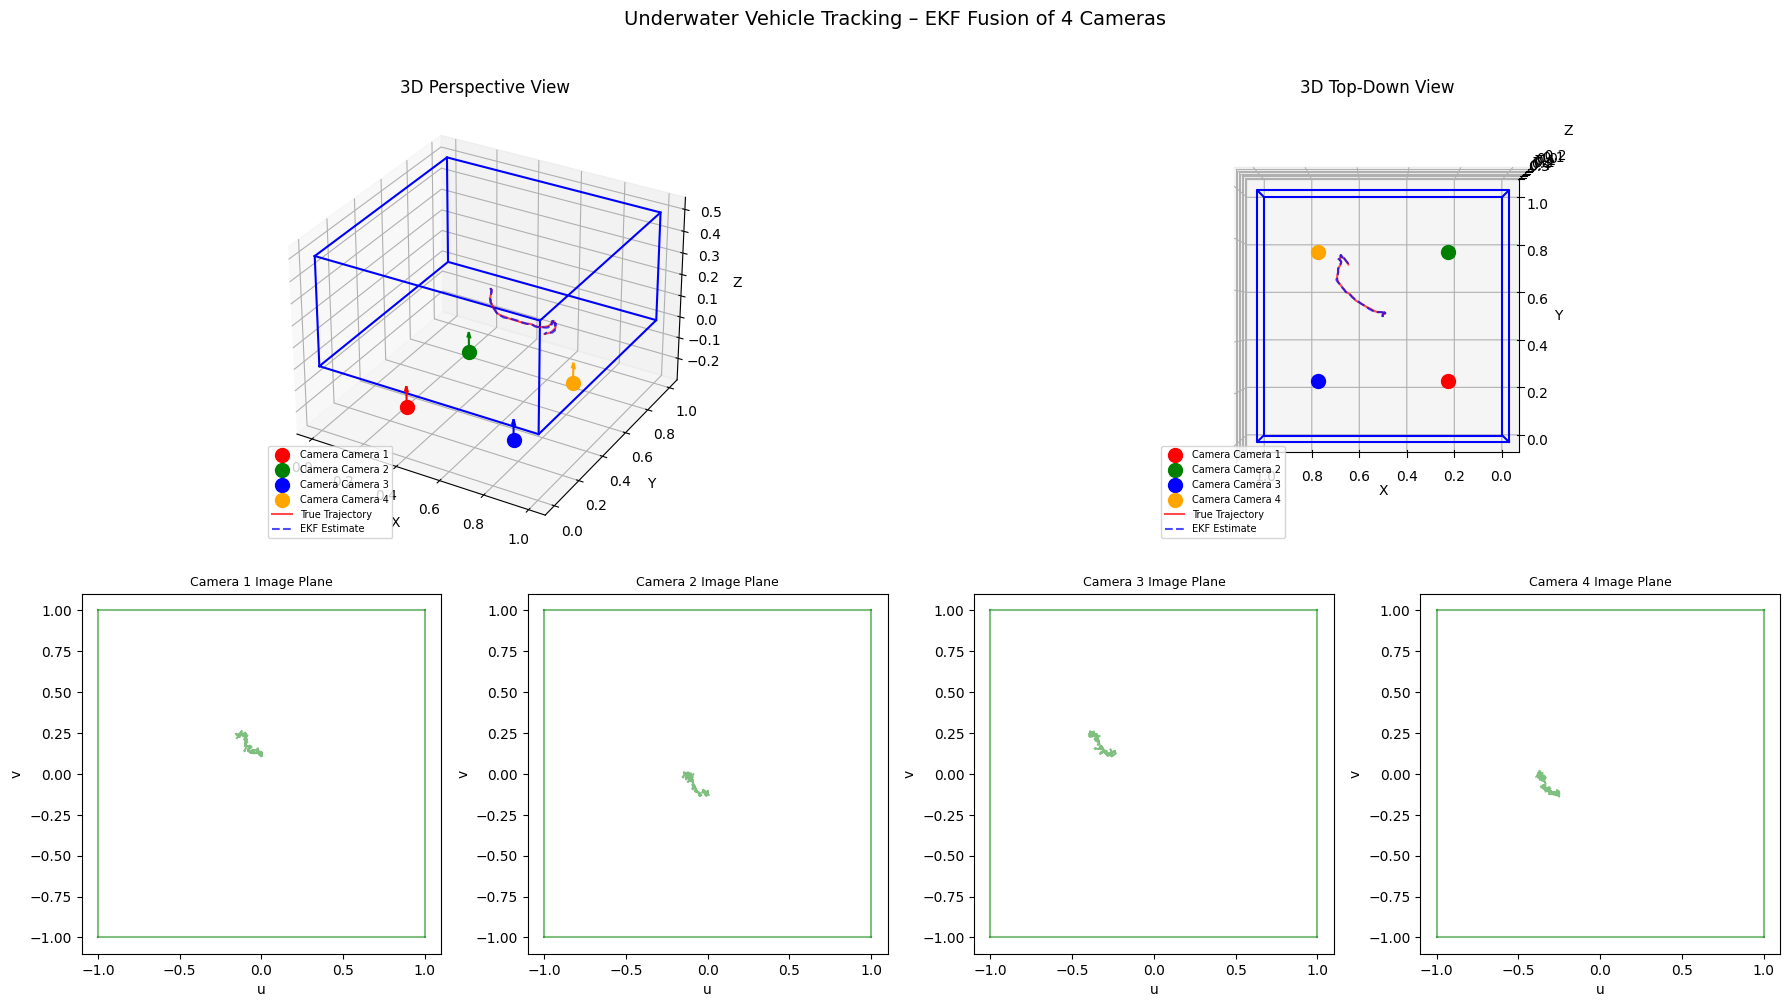

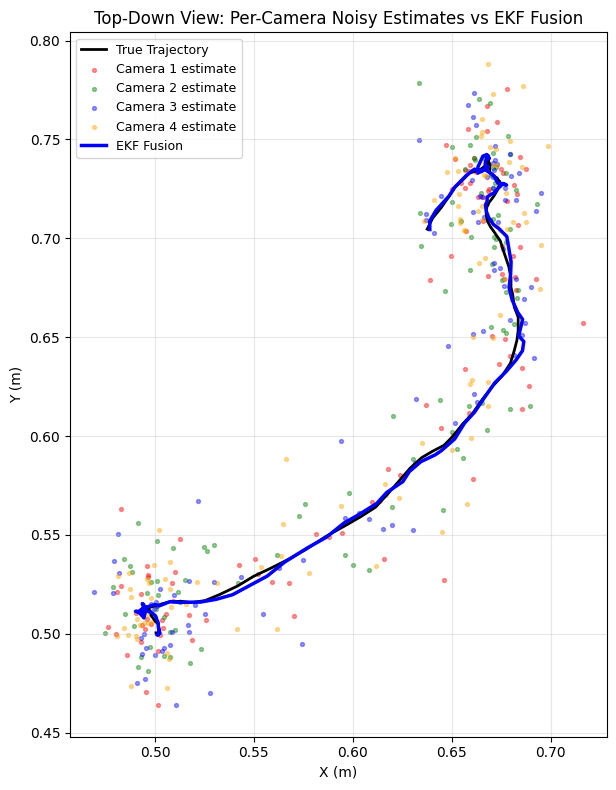

In [88]:
fig = plt.figure(figsize=(18, 10))

# ── Row 1: 3D views ──
ax1 = fig.add_subplot(2, 4, (1, 2), projection='3d')
tank.plot_tank(ax1)
for cam in cameras:
    cam.plot_camera(ax1)
ax1.plot(true_positions[:, 0], true_positions[:, 1], true_positions[:, 2],
         'r-', alpha=0.7, label='True Trajectory')
ax1.plot(estimated_positions[:, 0], estimated_positions[:, 1], estimated_positions[:, 2],
         'b--', alpha=0.7, label='EKF Estimate')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.legend(fontsize=7); ax1.set_title('3D Perspective View')

ax2 = fig.add_subplot(2, 4, (3, 4), projection='3d')
tank.plot_tank(ax2)
for cam in cameras:
    cam.plot_camera(ax2)
ax2.plot(true_positions[:, 0], true_positions[:, 1], true_positions[:, 2],
         'r-', alpha=0.7, label='True Trajectory')
ax2.plot(estimated_positions[:, 0], estimated_positions[:, 1], estimated_positions[:, 2],
         'b--', alpha=0.7, label='EKF Estimate')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.legend(fontsize=7); ax2.set_title('3D Top-Down View')
ax2.view_init(elev=-90, azim=90)

# ── Row 2: camera image-plane trajectories (with noise) ──
for i, cam in enumerate(cameras):
    ax = fig.add_subplot(2, 4, i + 5)
    cam.plot_trajectory(ax)
    ax.set_title(f'{cam.name} Image Plane', fontsize=9)
    ax.set_xlabel('u'); ax.set_ylabel('v')
    ax.set_aspect('equal')

plt.suptitle('Underwater Vehicle Tracking – EKF Fusion of 4 Cameras', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Separate figure: top-down per-camera estimates vs EKF ──
fig2, ax_td = plt.subplots(figsize=(10, 8))
ax_td.plot(true_positions[:, 0], true_positions[:, 1],
           'k-', linewidth=2, label='True Trajectory')
for i, cam in enumerate(cameras):
    ests = per_camera_world_estimates[i]
    ax_td.scatter(ests[:, 0], ests[:, 1], s=8, alpha=0.4,
                  color=cam.color, label=f'{cam.name} estimate')
ax_td.plot(estimated_positions[:, 0], estimated_positions[:, 1],
           'b-', linewidth=2.5, label='EKF Fusion')
ax_td.set_xlabel('X (m)'); ax_td.set_ylabel('Y (m)')
ax_td.legend(fontsize=9, loc='best')
ax_td.set_title('Top-Down View: Per-Camera Noisy Estimates vs EKF Fusion')
ax_td.set_aspect('equal')
ax_td.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Calculate Tracking Error

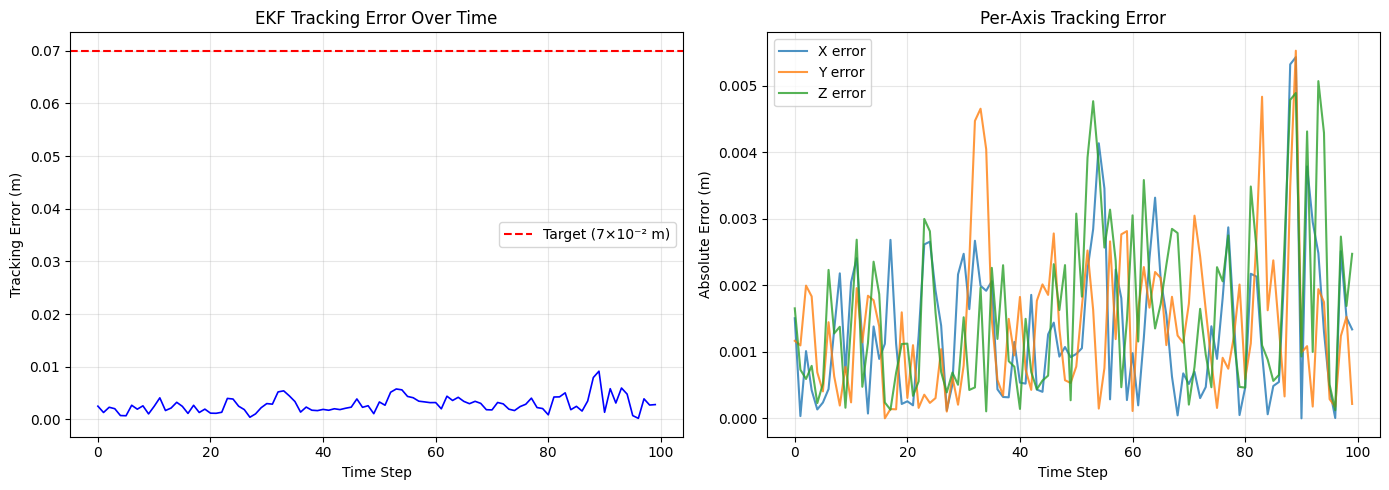

Mean error:   0.0029 m
Max error:    0.0092 m
Final error:  0.0028 m
Target:       0.0700 m
Within spec:  YES


In [89]:
errors = np.linalg.norm(true_positions - estimated_positions, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Euclidean error over time
axes[0].plot(errors, 'b-', linewidth=1.2)
axes[0].axhline(0.07, color='r', linestyle='--', label='Target (7×10⁻² m)')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Tracking Error (m)')
axes[0].set_title('EKF Tracking Error Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-axis error
labels = ['X', 'Y', 'Z']
for i, lbl in enumerate(labels):
    axes[1].plot(np.abs(true_positions[:, i] - estimated_positions[:, i]),
                 label=f'{lbl} error', alpha=0.8)
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Absolute Error (m)')
axes[1].set_title('Per-Axis Tracking Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean error:   {errors.mean():.4f} m")
print(f"Max error:    {errors.max():.4f} m")
print(f"Final error:  {errors[-1]:.4f} m")
print(f"Target:       0.0700 m")
print(f"Within spec:  {'YES' if errors.mean() < 0.07 else 'NO'}")